In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(  r"C:\Sqldata\covid19_modeling.csv",
    parse_dates=["Date"])

print(df.head())

        Date  Confirmed  Deaths  Recovered     Location
0 2020-02-24          5       0          0  Afghanistan
1 2020-02-25          5       0          0  Afghanistan
2 2020-02-26          5       0          0  Afghanistan
3 2020-02-27          5       0          0  Afghanistan
4 2020-02-28          5       0          0  Afghanistan


In [2]:
#Case stady

country_df = df[df["Location"] == "Germany"]

print(country_df.head())
print(country_df.shape)

            Date  Confirmed  Deaths  Recovered Location
60444 2020-01-27          1       0          0  Germany
60445 2020-01-28          4       0          0  Germany
60446 2020-01-29          4       0          0  Germany
60447 2020-01-30          4       0          0  Germany
60448 2020-01-31          5       0          0  Germany
(556, 5)


In [3]:
print(country_df.isnull().sum())

Date         0
Confirmed    0
Deaths       0
Recovered    0
Location     0
dtype: int64


In [4]:
print("Start Date:", country_df["Date"].min().date())
print("End Date:", country_df["Date"].max().date())

Start Date: 2020-01-27
End Date: 2021-08-04


In [5]:
print("Number of observations:", len(country_df))

Number of observations: 556


In [9]:
print("Confirmed Range:",
      country_df["Confirmed"].max() - country_df["Confirmed"].min())

print("Deaths Range:",
      country_df["Deaths"].max() - country_df["Deaths"].min())

print("Recovered Range:",
      country_df["Recovered"].max() - country_df["Recovered"].min())

Confirmed Range: 3777445
Deaths Range: 91704
Recovered Range: 3659260


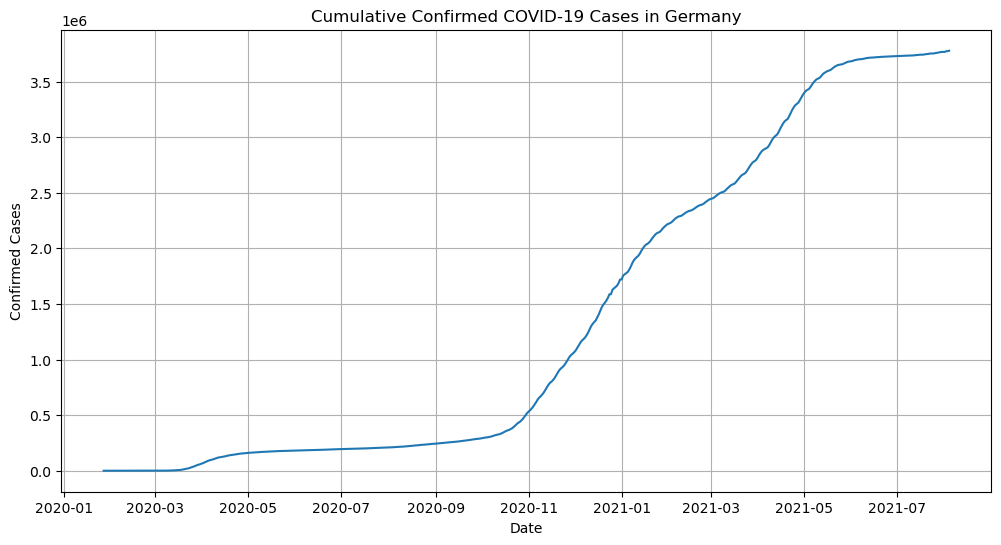

In [10]:
# Plot the number of confirrmed cases over time.

plt.figure(figsize=(12,6))

plt.plot(country_df["Date"], country_df["Confirmed"])

plt.title("Cumulative Confirmed COVID-19 Cases in Germany")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.grid(True)
plt.show()

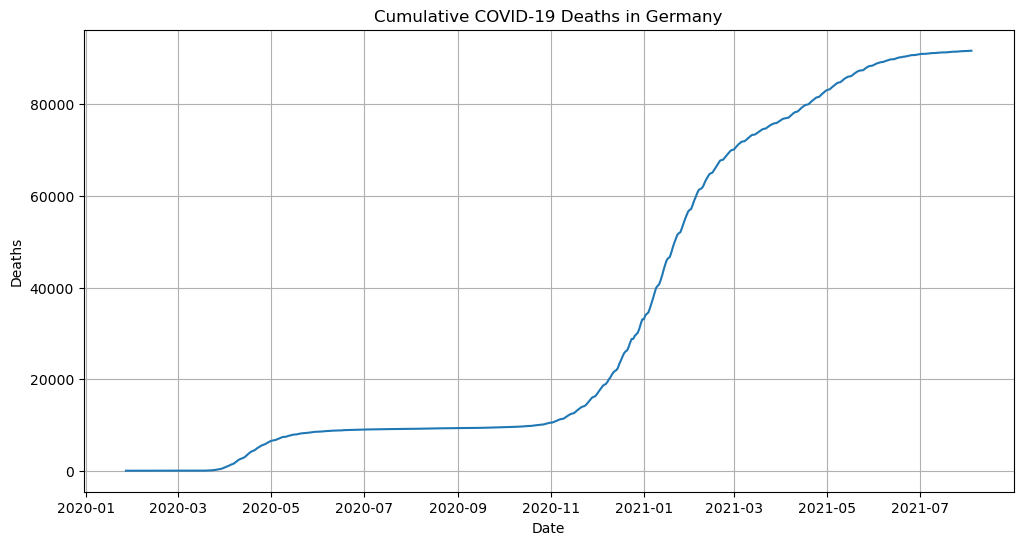

In [11]:
# Plot the number of deaths cases over time.


plt.figure(figsize=(12,6))

plt.plot(country_df["Date"], country_df["Deaths"])

plt.title("Cumulative COVID-19 Deaths in Germany")
plt.xlabel("Date")
plt.ylabel("Deaths")

plt.grid(True)
plt.show()

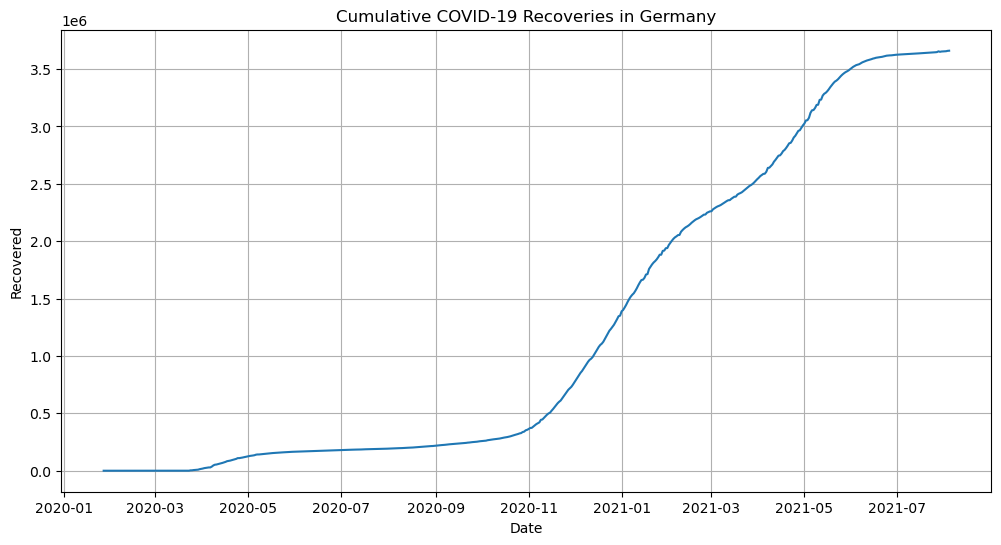

In [12]:


plt.figure(figsize=(12,6))

plt.plot(country_df["Date"], country_df["Recovered"])

plt.title("Cumulative COVID-19 Recoveries in Germany")
plt.xlabel("Date")
plt.ylabel("Recovered")

plt.grid(True)
plt.show()

In [14]:
country_df = country_df.copy()
country_df["Active"] = (
    country_df["Confirmed"]
    - country_df["Recovered"]
    - country_df["Deaths"]
)

print(country_df[["Date", "Confirmed", "Recovered", "Deaths", "Active"]].head())

            Date  Confirmed  Recovered  Deaths  Active
60444 2020-01-27          1          0       0       1
60445 2020-01-28          4          0       0       4
60446 2020-01-29          4          0       0       4
60447 2020-01-30          4          0       0       4
60448 2020-01-31          5          0       0       5


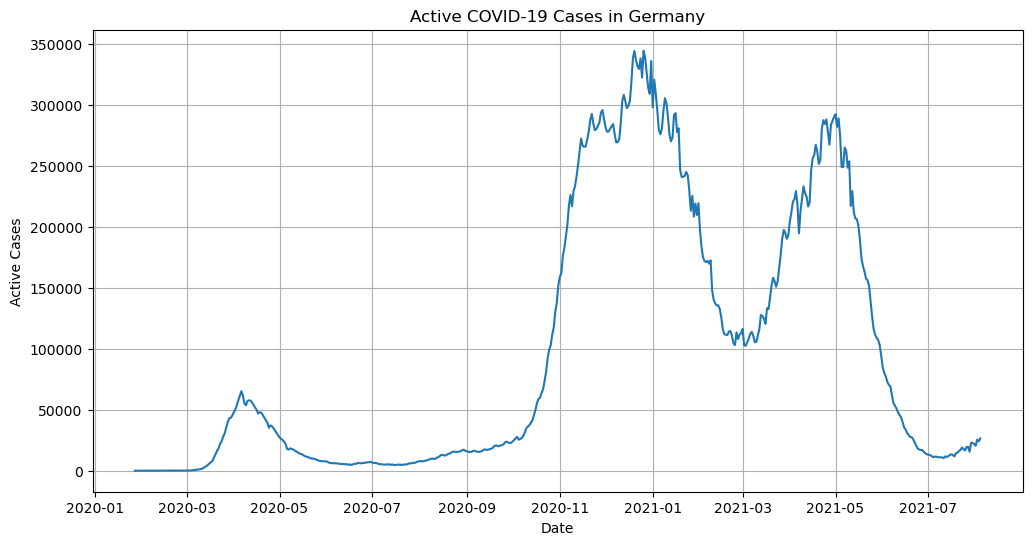

In [15]:
# Plot the number of active COVID-19 cases over time.
# This graph shows how the number of currently infected people changed in Germany.
# It helps identify the different waves of the pandemic and the periods with the highest disease burden.

plt.figure(figsize=(12,6))

plt.plot(country_df["Date"], country_df["Active"])

plt.title("Active COVID-19 Cases in Germany")
plt.xlabel("Date")
plt.ylabel("Active Cases")

plt.grid(True)
plt.show()

In [23]:
peak_active = country_df.loc[country_df["Active"].idxmax()]

print("Peak Active Cases")
print("Date:", peak_active["Date"].date())
print("Active Cases:", int(peak_active["Active"]))

Peak Active Cases
Date: 2020-12-26
Active Cases: 344396


In [24]:
#Since the dataset is cumulative, we calculate the daily changes using .diff().

country_df["DailyConfirmed"] = country_df["Confirmed"].diff()
country_df["DailyRecovered"] = country_df["Recovered"].diff()
country_df["DailyDeaths"] = country_df["Deaths"].diff()

In [17]:
print(country_df[[
    "Date",
    "Confirmed",
    "DailyConfirmed",
    "Recovered",
    "DailyRecovered",
    "Deaths",
    "DailyDeaths"
]].head())

            Date  Confirmed  DailyConfirmed  Recovered  DailyRecovered  \
60444 2020-01-27          1             NaN          0             NaN   
60445 2020-01-28          4             3.0          0             0.0   
60446 2020-01-29          4             0.0          0             0.0   
60447 2020-01-30          4             0.0          0             0.0   
60448 2020-01-31          5             1.0          0             0.0   

       Deaths  DailyDeaths  
60444       0          NaN  
60445       0          0.0  
60446       0          0.0  
60447       0          0.0  
60448       0          0.0  


In [18]:
#the NaN appear because there is no previous day.
#replace NaN with zero 
country_df[["DailyConfirmed", "DailyRecovered", "DailyDeaths"]] = (
    country_df[["DailyConfirmed", "DailyRecovered", "DailyDeaths"]]
    .fillna(0)
)

In [19]:
print(country_df[[
    "Date",
    "Confirmed",
    "DailyConfirmed",
    "Recovered",
    "DailyRecovered",
    "Deaths",
    "DailyDeaths"
]].head())

            Date  Confirmed  DailyConfirmed  Recovered  DailyRecovered  \
60444 2020-01-27          1             0.0          0             0.0   
60445 2020-01-28          4             3.0          0             0.0   
60446 2020-01-29          4             0.0          0             0.0   
60447 2020-01-30          4             0.0          0             0.0   
60448 2020-01-31          5             1.0          0             0.0   

       Deaths  DailyDeaths  
60444       0          0.0  
60445       0          0.0  
60446       0          0.0  
60447       0          0.0  
60448       0          0.0  


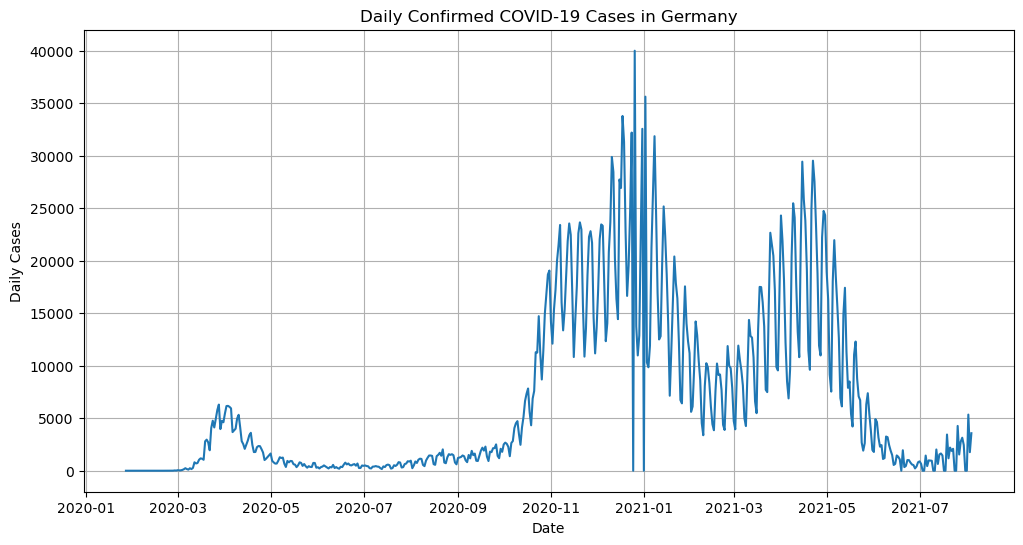

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(country_df["Date"], country_df["DailyConfirmed"])

plt.title("Daily Confirmed COVID-19 Cases in Germany")
plt.xlabel("Date")
plt.ylabel("Daily Cases")

plt.grid(True)
plt.show()

In [25]:
peak_confirmed = country_df.loc[country_df["DailyConfirmed"].idxmax()]

print("Peak Daily Confirmed Cases")
print("Date:", peak_confirmed["Date"].date())
print("Cases:", int(peak_confirmed["DailyConfirmed"]))

Peak Daily Confirmed Cases
Date: 2020-12-26
Cases: 39988


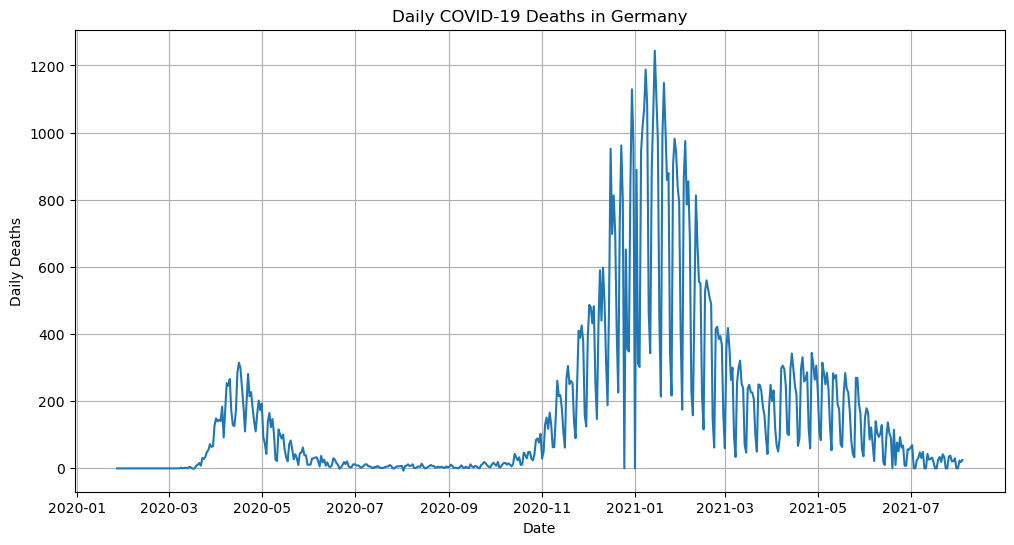

In [21]:
plt.figure(figsize=(12,6))
plt.plot(country_df["Date"], country_df["DailyDeaths"])

plt.title("Daily COVID-19 Deaths in Germany")
plt.xlabel("Date")
plt.ylabel("Daily Deaths")

plt.grid(True)
plt.show()

In [26]:
peak_deaths = country_df.loc[country_df["DailyDeaths"].idxmax()]

print("Peak Daily Deaths")
print("Date:", peak_deaths["Date"].date())
print("Deaths:", int(peak_deaths["DailyDeaths"]))

Peak Daily Deaths
Date: 2021-01-14
Deaths: 1244


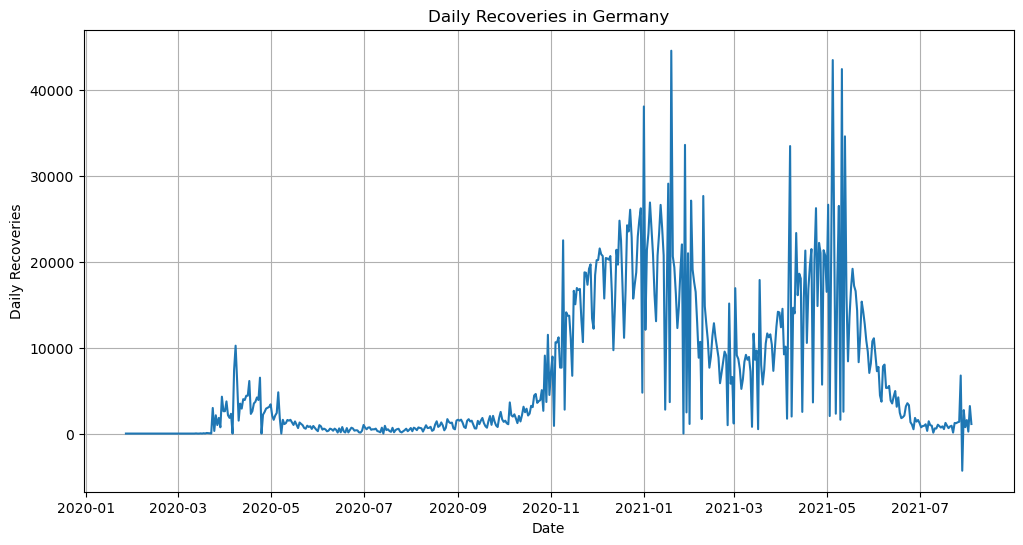

In [22]:
plt.figure(figsize=(12,6))
plt.plot(country_df["Date"], country_df["DailyRecovered"])

plt.title("Daily Recoveries in Germany")
plt.xlabel("Date")
plt.ylabel("Daily Recoveries")

plt.grid(True)
plt.show()

In [27]:
peak_recovered = country_df.loc[country_df["DailyRecovered"].idxmax()]

print("Peak Daily Recoveries")
print("Date:", peak_recovered["Date"].date())
print("Recoveries:", int(peak_recovered["DailyRecovered"]))

Peak Daily Recoveries
Date: 2021-01-19
Recoveries: 44517


In [28]:
print("Average Daily Confirmed:", round(country_df["DailyConfirmed"].mean(), 2))
print("Average Daily Deaths:", round(country_df["DailyDeaths"].mean(), 2))
print("Average Daily Recoveries:", round(country_df["DailyRecovered"].mean(), 2))

Average Confirmed Cases: 6806.21
Average Deaths: 165.23
Average Recoveries: 6593.26


In [29]:
print("Maximum Daily Confirmed:", int(country_df["DailyConfirmed"].max()))
print("Maximum Daily Deaths:", int(country_df["DailyDeaths"].max()))
print("Maximum Daily Recoveries:", int(country_df["DailyRecovered"].max()))

Maximum Daily Confirmed: 39988
Maximum Daily Deaths: 1244
Maximum Daily Recoveries: 44517


In [32]:
#Avarage weekly cases 
country_df["Confirmed_7Day"] = (
    country_df["DailyConfirmed"]
    .rolling(window=7, center=True)
    .mean()
)

country_df["Deaths_7Day"] = (
    country_df["DailyDeaths"]
    .rolling(window=7, center=True)
    .mean()
)

country_df["Recovered_7Day"] = (
    country_df["DailyRecovered"]
    .rolling(window=7, center=True)
    .mean()
)


Average Weekly Confirmed: 60444            NaN
60445            NaN
60446            NaN
60447            NaN
60448       1.571429
            ...     
60995    2210.571429
60996    2325.285714
60997            NaN
60998            NaN
60999            NaN
Name: Confirmed_7Day, Length: 556, dtype: float64
Average Weekly Deaths: 60444          NaN
60445          NaN
60446          NaN
60447          NaN
60448     0.000000
           ...    
60995    16.285714
60996    16.857143
60997          NaN
60998          NaN
60999          NaN
Name: Deaths_7Day, Length: 556, dtype: float64
Average Weekly Recoveries: 60444            NaN
60445            NaN
60446            NaN
60447            NaN
60448       0.000000
            ...     
60995    1558.571429
60996     752.857143
60997            NaN
60998            NaN
60999            NaN
Name: Recovered_7Day, Length: 556, dtype: float64


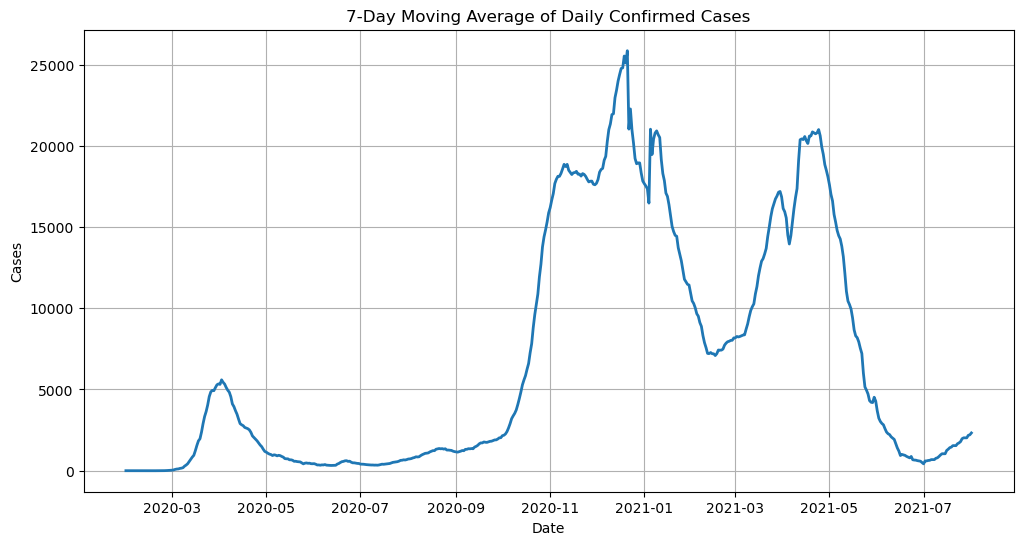

In [31]:

plt.figure(figsize=(12,6))

plt.plot(
    country_df["Date"],
    country_df["Confirmed_7Day"],
    linewidth=2
)

plt.title("7-Day Moving Average of Daily Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.grid(True)
plt.show()

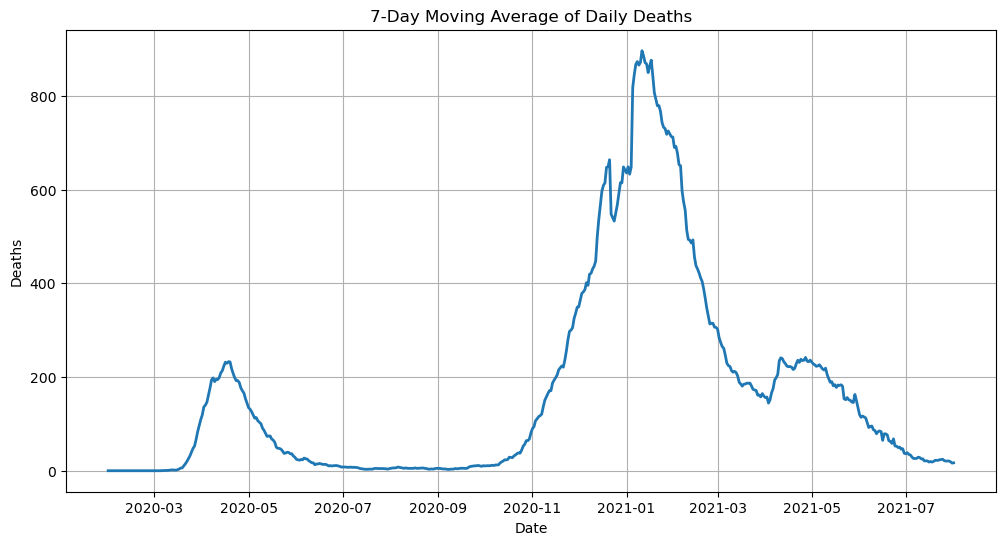

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    country_df["Date"],
    country_df["Deaths_7Day"],
    linewidth=2
)

plt.title("7-Day Moving Average of Daily Deaths")
plt.xlabel("Date")
plt.ylabel("Deaths")

plt.grid(True)
plt.show()

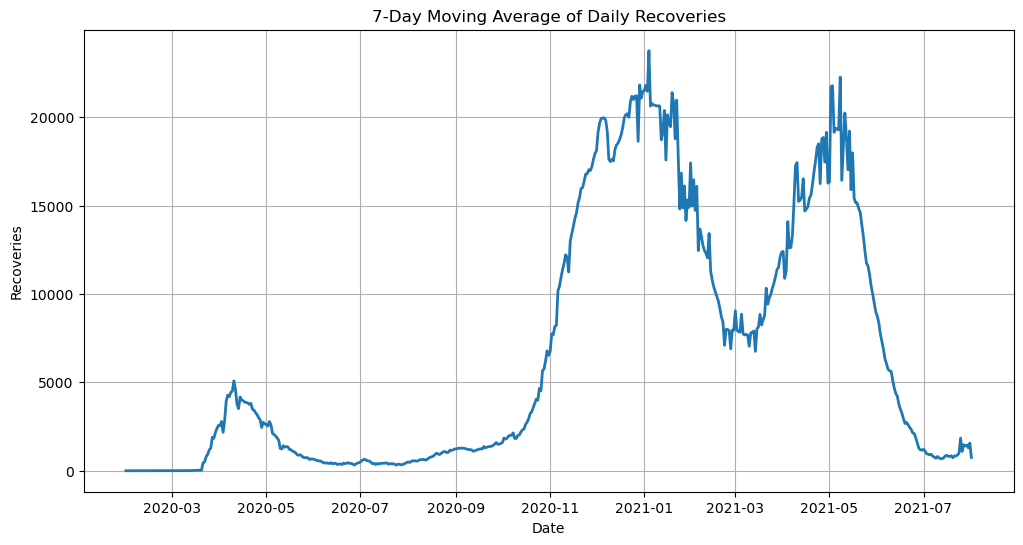

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    country_df["Date"],
    country_df["Recovered_7Day"],
    linewidth=2
)

plt.title("7-Day Moving Average of Daily Recoveries")
plt.xlabel("Date")
plt.ylabel("Recoveries")

plt.grid(True)
plt.show()